# 💳 Fraud Detection — Stage 3: Handling Class Imbalance

In Stage 2 we used `class_weight='balanced'` to handle imbalance — a quick,
built-in lever. It boosted recall (87%) but at the cost of 1,396 false alarms.

This stage explores a different family of techniques: **resampling** — physically
changing the training data so fraud and legit are closer to balanced *before*
the model ever sees it. We'll try:

1. **SMOTE** (Synthetic Minority Oversampling Technique) — create new synthetic
   fraud samples to grow the minority class
2. **Random undersampling** — delete legit samples to shrink the majority class
3. **SMOTE + undersampling combined** — a middle path that keeps more data than
   pure undersampling but is less extreme than pure SMOTE

All three use `imbalanced-learn`, a library purpose-built for this.

The goal of this stage is to understand *what* these techniques do and *why*,
not just to improve a number — because the real payoff comes in Stage 4 when
we combine them with more powerful tree-based models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")

# ── Reproduce the same split as Stage 2 ────────────────────────────────────
df = pd.read_csv("../data/raw/creditcard.csv").drop_duplicates()
X = df.drop("Class", axis=1).copy()
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]]  = scaler.transform(X_test[["Time", "Amount"]])

print(f"Train: {len(X_train):,} rows | fraud: {y_train.sum()}")
print(f"Test:  {len(X_test):,} rows  | fraud: {y_test.sum()}")

Train: 226,980 rows | fraud: 378
Test:  56,746 rows  | fraud: 95


## 1. SMOTE — synthetic minority oversampling

SMOTE does not simply duplicate existing fraud rows (which would add no new
information). Instead, for each fraud sample it:

1. Finds its k nearest fraud neighbours in feature space
2. Picks one of those neighbours at random
3. Creates a new synthetic point **somewhere along the line segment** between
   the original sample and that neighbour

The result: new synthetic fraud samples that are plausible interpolations of
real fraud cases, spread through the fraud region of feature space rather than
stacked exactly on top of existing points.

By default, SMOTE oversamples the minority class until it matches the majority
(50/50 split). That creates a lot of synthetic data — but it all stays in the
**training set**. The test set is never touched, so evaluation stays honest.

In [2]:
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {len(X_train):,} rows | fraud: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"After  SMOTE: {len(X_sm):,} rows   | fraud: {y_sm.sum():,} ({y_sm.mean()*100:.1f}%)")

Before SMOTE: 226,980 rows | fraud: 378 (0.17%)
After  SMOTE: 453,204 rows   | fraud: 226,602 (50.0%)


In [3]:
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_sm, y_sm)

y_pred_sm = lr_smote.predict(X_test)
y_prob_sm = lr_smote.predict_proba(X_test)[:, 1]

roc_sm = round(float(roc_auc_score(y_test, y_prob_sm)), 4)
pr_sm  = round(float(average_precision_score(y_test, y_prob_sm)), 4)

print(classification_report(y_test, y_pred_sm, target_names=["legit", "fraud"], digits=4))
print(f"ROC-AUC: {roc_sm}  |  PR-AUC: {pr_sm}")
print("Confusion matrix:", confusion_matrix(y_test, y_pred_sm))

              precision    recall  f1-score   support

       legit     0.9998    0.9738    0.9866     56651
       fraud     0.0530    0.8737    0.1000        95

    accuracy                         0.9737     56746
   macro avg     0.5264    0.9238    0.5433     56746
weighted avg     0.9982    0.9737    0.9852     56746

ROC-AUC: 0.9619  |  PR-AUC: 0.6769
Confusion matrix: [[55169  1482]
 [   12    83]]


**SMOTE results:** ROC-AUC 0.9619 · PR-AUC 0.6769 · Recall 0.87 · False alarms: 1,482

Almost identical to the balanced class-weights baseline from Stage 2 (ROC-AUC
0.9658, PR-AUC 0.6720, 1,396 false alarms). Same recall, similar false alarm
count, slightly lower PR-AUC.

**Why doesn't SMOTE dramatically outperform here?** Logistic regression is a
*linear* model — it draws a straight hyperplane through feature space. SMOTE's
synthetic points fill in the minority region, but a hyperplane can only move
in one direction; you're still limited by the model's expressiveness. SMOTE's
power really shows up with **non-linear models** (decision trees, random
forests, XGBoost) that can exploit the richer decision boundary. That's Stage 4.

## 2. Random undersampling

Instead of creating more fraud samples, we can randomly **delete** legit
transactions until the classes are balanced. It's the opposite direction:
shrink the majority down to match the minority.

The obvious downside: we throw away real data. With 226,580 legit transactions
in training, we'd keep only 378 — discarding 99.8% of legitimate examples.
That's drastic, but it's also very fast (tiny training set) and sometimes
surprisingly effective.

In [4]:
under = RandomUnderSampler(random_state=42)
X_ru, y_ru = under.fit_resample(X_train, y_train)

print(f"Before undersampling: {len(X_train):,} rows | fraud: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"After  undersampling: {len(X_ru):,} rows     | fraud: {y_ru.sum()} ({y_ru.mean()*100:.1f}%)")

Before undersampling: 226,980 rows | fraud: 378 (0.17%)
After  undersampling: 756 rows     | fraud: 378 (50.0%)


In [5]:
lr_under = LogisticRegression(max_iter=1000, random_state=42)
lr_under.fit(X_ru, y_ru)

y_pred_ru = lr_under.predict(X_test)
y_prob_ru = lr_under.predict_proba(X_test)[:, 1]

roc_ru = round(float(roc_auc_score(y_test, y_prob_ru)), 4)
pr_ru  = round(float(average_precision_score(y_test, y_prob_ru)), 4)

print(classification_report(y_test, y_pred_ru, target_names=["legit", "fraud"], digits=4))
print(f"ROC-AUC: {roc_ru}  |  PR-AUC: {pr_ru}")
print("Confusion matrix:", confusion_matrix(y_test, y_pred_ru))

              precision    recall  f1-score   support

       legit     0.9998    0.9732    0.9863     56651
       fraud     0.0519    0.8737    0.0980        95

    accuracy                         0.9731     56746
   macro avg     0.5258    0.9235    0.5422     56746
weighted avg     0.9982    0.9731    0.9848     56746

ROC-AUC: 0.9559  |  PR-AUC: 0.6182
Confusion matrix: [[55135  1516]
 [   12    83]]


**Undersampling results:** ROC-AUC 0.9559 · PR-AUC 0.6182 · Recall 0.87 · False alarms: 1,516

Recall is identical to SMOTE but PR-AUC dropped to 0.62. Throwing away 99.8%
of the legit training data hurts the model's ability to precisely characterise
the legitimate class — it can still find fraud, but it gets sloppier about
what counts as "normal", generating more false alarms.

Undersampling is most useful when the dataset is enormous and training time is
a constraint, or as one half of the combo strategy next.

## 3. SMOTE + undersampling combined

Rather than going to a full 50/50 split in one direction or the other, we can
do both at a moderate level:

1. **SMOTE first** — grow fraud to 10% of legit (`sampling_strategy=0.1`)
2. **Undersample second** — shrink legit until fraud is 33% of total
   (`sampling_strategy=0.5` means minority:majority = 0.5)

This creates less extreme synthetic data than full SMOTE (fraud goes to 10%
rather than 50% before undersampling kicks in) while keeping more real legit
samples than pure undersampling. `imbalanced-learn` provides a `Pipeline` to
chain these steps cleanly.

In [6]:
combo_pipeline = Pipeline([
    ("over",  SMOTE(sampling_strategy=0.1, random_state=42)),
    ("under", RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
])
X_combo, y_combo = combo_pipeline.fit_resample(X_train, y_train)

print(f"Before combo: {len(X_train):,} rows | fraud: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"After  combo: {len(X_combo):,} rows  | fraud: {y_combo.sum():,} ({y_combo.mean()*100:.1f}%)")

Before combo: 226,980 rows | fraud: 378 (0.17%)
After  combo: 67,980 rows  | fraud: 22,660 (33.3%)


In [7]:
lr_combo = LogisticRegression(max_iter=1000, random_state=42)
lr_combo.fit(X_combo, y_combo)

y_pred_combo = lr_combo.predict(X_test)
y_prob_combo = lr_combo.predict_proba(X_test)[:, 1]

roc_combo = round(float(roc_auc_score(y_test, y_prob_combo)), 4)
pr_combo  = round(float(average_precision_score(y_test, y_prob_combo)), 4)

print(classification_report(y_test, y_pred_combo, target_names=["legit", "fraud"], digits=4))
print(f"ROC-AUC: {roc_combo}  |  PR-AUC: {pr_combo}")
print("Confusion matrix:", confusion_matrix(y_test, y_pred_combo))

              precision    recall  f1-score   support

       legit     0.9998    0.9881    0.9939     56651
       fraud     0.1094    0.8737    0.1944        95

    accuracy                         0.9879     56746
   macro avg     0.5546    0.9309    0.5941     56746
weighted avg     0.9983    0.9879    0.9926     56746

ROC-AUC: 0.9636  |  PR-AUC: 0.6548
Confusion matrix: [[55975   676]
 [   12    83]]


**Combo results:** ROC-AUC 0.9636 · PR-AUC 0.6548 · Recall 0.87 · False alarms: 676

Same recall (87%), but false alarms dropped from ~1,500 to 676 — less than half
of SMOTE alone or undersampling alone. Precision on fraud more than doubled
(from 5% to 11%). The moderate ratio preserved enough real legit data to better
define the legitimate boundary, without the extreme data loss of pure
undersampling.

## 4. Comparison across all strategies

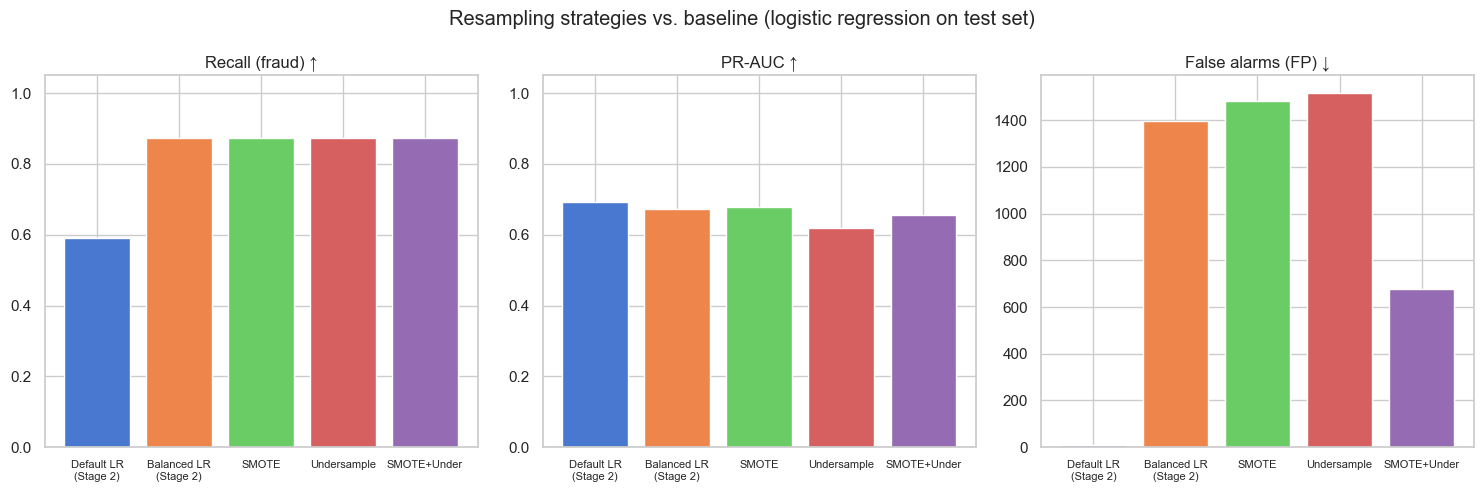

In [8]:
results = {
    "Default LR\n(Stage 2)": {"recall": 0.5895, "precision": 0.8485, "roc": 0.9584, "pr": 0.6935, "fp": 10},
    "Balanced LR\n(Stage 2)": {"recall": 0.8737, "precision": 0.0561, "roc": 0.9658, "pr": 0.6720, "fp": 1396},
    "SMOTE": {"recall": 0.8737, "precision": 0.0530, "roc": roc_sm, "pr": pr_sm, "fp": 1482},
    "Undersample": {"recall": 0.8737, "precision": 0.0519, "roc": roc_ru, "pr": pr_ru, "fp": 1516},
    "SMOTE+Under": {"recall": 0.8737, "precision": 0.1094, "roc": roc_combo, "pr": pr_combo, "fp": 676},
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels = list(results.keys())
colors = ["#4878d0", "#ee854a", "#6acc65", "#d65f5f", "#956cb4"]

axes[0].bar(labels, [v["recall"] for v in results.values()], color=colors)
axes[0].set_title("Recall (fraud) ↑")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', labelsize=8)

axes[1].bar(labels, [v["pr"] for v in results.values()], color=colors)
axes[1].set_title("PR-AUC ↑")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', labelsize=8)

axes[2].bar(labels, [v["fp"] for v in results.values()], color=colors)
axes[2].set_title("False alarms (FP) ↓")
axes[2].tick_params(axis='x', labelsize=8)

plt.suptitle("Resampling strategies vs. baseline (logistic regression on test set)")
plt.tight_layout()
plt.savefig("../reports/figures/resampling_comparison.png", dpi=150)
plt.show()

## 5. Precision-Recall curves side-by-side

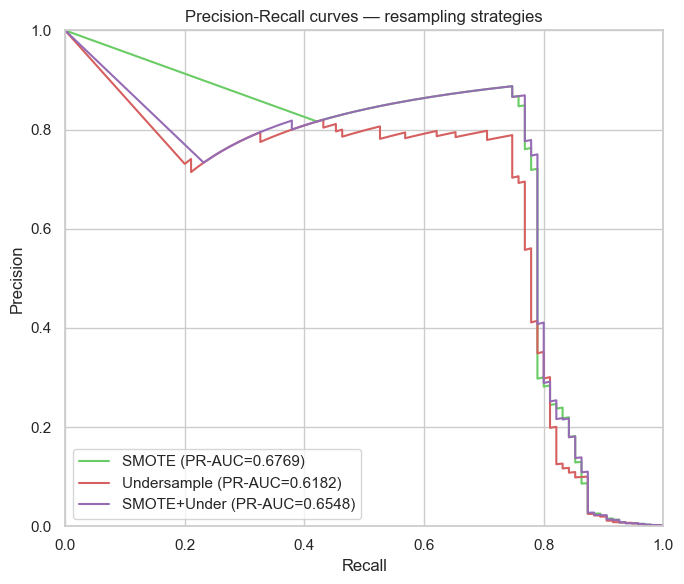

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
for label, probs, color in [
    (f"SMOTE (PR-AUC={pr_sm})",         y_prob_sm,    "#6acc65"),
    (f"Undersample (PR-AUC={pr_ru})",   y_prob_ru,    "#d65f5f"),
    (f"SMOTE+Under (PR-AUC={pr_combo})",y_prob_combo, "#956cb4"),
]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ax.plot(rec, prec, label=label, color=color)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves — resampling strategies")
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig("../reports/figures/resampling_pr_curves.png", dpi=150)
plt.show()

## 6. Summary and what to expect from tree models

| Strategy | ROC-AUC | PR-AUC | Recall | False alarms |
|---|---|---|---|---|
| Default LR (Stage 2 baseline) | 0.9584 | **0.6935** | 0.59 | 10 |
| Balanced class weights (Stage 2) | 0.9658 | 0.6720 | 0.87 | 1,396 |
| SMOTE | 0.9619 | 0.6769 | 0.87 | 1,482 |
| Random undersampling | 0.9559 | 0.6182 | 0.87 | 1,516 |
| **SMOTE + undersampling** | **0.9636** | **0.6548** | **0.87** | **676** |

Three honest conclusions:

1. **Resampling alone doesn't dramatically beat class weighting** when the base
   model is logistic regression. We're bottlenecked by the linear model, not
   by the data strategy.

2. **SMOTE + undersampling combo is the best tradeoff** of those tried —
   same recall as the others but half as many false alarms.

3. **The real payoff of SMOTE is with non-linear models.** Decision trees and
   ensemble models (random forest, XGBoost) can draw complex boundaries in
   feature space. SMOTE gives them more fraud territory to learn from, which
   can produce large improvements. That's what we test in Stage 4.

**Baseline to beat (PR-AUC): 0.6935**  
**Next up (`04_tree_models.ipynb`):** Random Forest and XGBoost — models that
can learn non-linear patterns in the V features and combine with SMOTE for a
meaningful jump in PR-AUC.